<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/05_first_ml_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- nav-header -->
[⬅ Previous](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/04_time_series_feature_engineering.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · **Notebook 05 of the course** · [Next: 06 — Evaluating like a clinician ➡](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/06_model_evaluation.ipynb)


# 🩺 Notebook 05 — Your first predictive models

> You have a clean, one-row-per-patient table (from Notebook 04). Now we ask the
> question every clinician cares about: **can we predict which sepsis patients will die
> within 90 days — and how well?** In this notebook you build your first machine-learning
> models the *right* way, using scikit-learn.

**What you'll learn**
- How to frame a clinical outcome as a supervised-learning problem (features `X`, label `y`) — and
  whether this is a **time-series forecast or a one-time, whole-stay prediction** (spoiler: the latter).
- Why you must **split your data before you touch it** — and how to split *by patient*.
- How to build a leak-free **pipeline** (impute → scale → model) and a **baseline** to beat.
- Three workhorse models: **logistic regression**, **random forest**, **XGBoost**.
- How to compare them honestly with **ROC-AUC**, **cross-validation**, and a first look at
  **feature importance**.

**⏱️ Time:** ≈80 min · **Prerequisites:** Notebook 04 (which builds the patient table)


### ⚙️ Run me first
Run the setup cell below once. It installs anything missing, sets a clean plotting style, and defines the data loaders. (Same cell as every notebook — no need to read it in detail.)

In [1]:
# === ⚙️  Workshop setup — run this cell first ===============================
# Works in Google Colab and in local Jupyter. Installs anything missing, sets a
# clean plotting style, and gives you helpers to load the data.
# (This cell is identical in every notebook of the course.)
import importlib.util, subprocess, sys, os, random, warnings
warnings.filterwarnings("ignore")

# --- reproducibility: everyone in the room gets the same numbers ---------------
RANDOM_STATE = 42
os.environ["PYTHONHASHSEED"] = str(RANDOM_STATE)
random.seed(RANDOM_STATE)

# 📥 Where the workshop data comes from — already set up for you, nothing to do.
# The data downloads automatically the first time you need it. If you were given a
# different link, just paste it in place of the one below. These forms all work:
#   • a Google-Drive folder link      • a Drive / Dropbox / OneDrive file link
#   • a folder URL ending in "/"      • a link straight to a .zip
# Set it to "" if you would rather upload the CSVs by hand.
# (The data is not in the GitHub repo: it is real de-identified patient data covered
#  by a data use agreement and may not be redistributed openly.)
WORKSHOP_DATA_URL = os.environ.get(
    "WORKSHOP_DATA_URL",
    "https://drive.google.com/drive/folders/1y7CparhrqdlCAZq6xQlj8fZda394fniD")

def _ensure(pkgs):
    missing = [pip for mod, pip in pkgs.items() if importlib.util.find_spec(mod) is None]
    if missing:
        print("Installing:", *missing)
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing])
_ensure({"numpy":"numpy","pandas":"pandas","sklearn":"scikit-learn",
         "matplotlib":"matplotlib","seaborn":"seaborn","shap":"shap","xgboost":"xgboost"})

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
np.random.seed(RANDOM_STATE)          # seeds the legacy global np.random.* calls
RNG = np.random.default_rng(RANDOM_STATE)   # the modern generator — use this one
pd.set_option("display.max_columns", 120); pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (9, 5); plt.rcParams["figure.dpi"] = 110

# Every model, split and resample in this course passes random_state=RANDOM_STATE, so
# your numbers should match your neighbour's exactly. (Different library *versions* can
# still shift the last decimal — that is normal and not a mistake on your part.)

# --- data loading: works locally AND remembers your upload across notebooks -----
_CACHE = {"dir": "unset"}   # memo so we only touch Google Drive once per session

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _drive_cache():
    """In Google Colab, mount Drive ONCE and return a persistent folder. A file you
    upload in one notebook is saved here, so every other notebook opens it automatically
    — no re-uploading. Returns None outside Colab, or if you decline to connect Drive."""
    if _CACHE["dir"] != "unset":
        return _CACHE["dir"]
    result = None
    if _in_colab():
        try:
            from google.colab import drive
            if not os.path.ismount("/content/drive"):
                drive.mount("/content/drive")
            result = "/content/drive/MyDrive/sepsis_workshop_data"
            os.makedirs(result, exist_ok=True)
        except Exception:
            result = None
    _CACHE["dir"] = result
    return result

def _find(name):
    """Look for the file on disk. Deliberately does NOT touch Google Drive, so the normal
    path never triggers an authorisation popup."""
    for p in [name, f"data/{name}", f"../data/{name}", f"workshop/data/{name}"]:
        if os.path.exists(p):
            return p
    return None

def _find_in_drive(name):
    """Only used as a fallback, because it mounts Drive (and that means a popup)."""
    cache = _drive_cache()
    if cache:
        p = os.path.join(cache, name)
        if os.path.exists(p):
            return p
    return None

def _direct_url(u):
    """Turn an ordinary Google-Drive / Dropbox / OneDrive *share* link into one that a
    plain HTTP client can actually download, so you can paste the link you were given."""
    import re
    m = (re.search(r"drive\.google\.com/file/d/([\w-]+)", u)
         or re.search(r"drive\.google\.com/(?:open|uc)\?(?:export=\w+&)?id=([\w-]+)", u))
    if m:
        return f"https://drive.google.com/uc?export=download&id={m.group(1)}"
    if "dropbox.com" in u:
        return u.split("?")[0] + "?dl=1"
    if "sharepoint.com" in u or "1drv.ms" in u:
        return u + ("&" if "?" in u else "?") + "download=1"
    return u

def _fetch(url, dest):
    import urllib.request, shutil as _sh
    req = urllib.request.Request(_direct_url(url), headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=120) as r, open(dest, "wb") as f:
        _sh.copyfileobj(r, f)

_FOLDER = {"done": False}

def _gdrive_folder(name):
    """WORKSHOP_DATA_URL points at a Google-Drive *folder*: fetch it once with gdown
    (a folder cannot be downloaded with a plain HTTP request), then serve files from it."""
    dest = "_workshop_data"
    if not _FOLDER["done"]:
        _ensure({"gdown": "gdown"})
        import gdown
        print("⬇  fetching the workshop data from Google Drive (just once) …")
        gdown.download_folder(url=WORKSHOP_DATA_URL, output=dest, quiet=True, use_cookies=False)
        _FOLDER["done"] = True
    for root, _dirs, files in os.walk(dest):
        if name in files:
            return os.path.join(root, name)
    return None

def _try_download(name):
    """Fetch the data from WORKSHOP_DATA_URL, if one was configured."""
    u = (WORKSHOP_DATA_URL or "").strip()
    if not u:
        return None
    try:
        if "/drive/folders/" in u:
            return _gdrive_folder(name)
        if u.lower().split("?")[0].endswith(".zip"):
            import zipfile
            bundle = "_workshop_data.zip"
            if not os.path.exists(bundle):
                print("⬇  downloading the workshop data bundle …")
                _fetch(u, bundle)
            with zipfile.ZipFile(bundle) as z:      # flatten any folder inside the zip
                for member in z.namelist():
                    if os.path.basename(member) == name:
                        with z.open(member) as src, open(name, "wb") as dst:
                            dst.write(src.read())
                        return name
            print(f"  ({name} was not inside the bundle)")
            return None
        print(f"⬇  downloading {name} …")
        _fetch(u.rstrip("/") + "/" + name, name)
        return name
    except Exception as e:
        print(f"  (download failed: {e})")
        for leftover in (name, "_workshop_data.zip"):
            if os.path.exists(leftover) and os.path.getsize(leftover) == 0:
                os.remove(leftover)
        return None

def _cache_to_drive(name, data):
    cache = _drive_cache()
    if cache:
        dest = os.path.join(cache, name)
        data.to_csv(dest, index=False)
        print(f"  💾 saved to Google Drive ({dest}) — no need to fetch it again.")

def load_csv(name):
    """Load a data CSV: looks on disk, then downloads it from WORKSHOP_DATA_URL, then checks
    your Google-Drive cache, and only as a last resort asks you to upload it — in which case
    it saves a copy to Drive so you never have to upload it twice."""
    p = _find(name)                       # 1. already on disk?
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    p = _try_download(name)               # 2. the built-in download link
    if p:
        print(f"✓ loaded {name}")
        return pd.read_csv(p)
    p = _find_in_drive(name)              # 3. a copy you saved on a previous run
    if p:
        print(f"✓ loaded {p}")
        return pd.read_csv(p)
    try:                                  # 4. last resort: upload it by hand
        from google.colab import files
        print(f"⤴  Upload {name} just once — I'll save it so the other notebooks open it automatically:")
        up = files.upload()
        fname = list(up.keys())[0]
        data = pd.read_csv(fname)
        _cache_to_drive(name, data)
        return data
    except Exception:
        raise FileNotFoundError(
            f"Could not find {name}. Either paste your download link into WORKSHOP_DATA_URL at "
            f"the top of this cell, or put the CSV next to this notebook / in a data/ folder."
        )


### 📥 Load the patient table

Notebook 04 turned the 4-hourly time-series into **one row per ICU stay**. The helper below is
that exact aggregation — if the pre-built `sepsis_patients.csv` is present it just loads it,
otherwise it rebuilds it from the time-series file. Run it, then `patients = load_patients()`.

In [2]:
def build_patient_table(ts):
    """Aggregate the 4-hourly time-series into ONE row per ICU stay.
       (This is exactly what Notebook 04 teaches you to build.)"""
    df = ts.copy()
    # clean temperature: prefer Celsius; repair obvious Fahrenheit-entry errors; drop impossible
    tf = df["Temp_F"].where((df["Temp_F"] >= 90) & (df["Temp_F"] <= 110))
    tc = df["Temp_C"].where((df["Temp_C"] >= 25) & (df["Temp_C"] <= 45))
    df["Temp_C_clean"] = tc.fillna((tf - 32) * 5/9)
    # impossible vitals -> NaN, then forward/back-fill WITHIN each stay
    for c, lo, hi in [("HR",20,300),("SysBP",40,300),("MeanBP",20,220),("RR",3,80),("SpO2",30,100)]:
        df[c] = df[c].where((df[c] >= lo) & (df[c] <= hi))
    g = df.groupby("icustayid", group_keys=False)
    vit = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean"]
    df[vit] = g[vit].apply(lambda x: x.ffill().bfill())
    # winsorise skewed labs so one stray value can't define a min/max
    for c in ["Arterial_lactate","Creatinine","BUN","WBC_count","Platelets_count","INR","Glucose"]:
        lo, hi = df[c].quantile(0.01), df[c].quantile(0.99)
        df[c] = df[c].clip(lo, hi)
    tv = ["HR","SysBP","MeanBP","RR","SpO2","Temp_C_clean","GCS","Creatinine","BUN",
          "Arterial_lactate","WBC_count","Platelets_count","Potassium","Sodium",
          "Albumin","INR","Arterial_pH","Shock_Index","SOFA","SIRS","PaO2_FiO2","Hb"]
    grp = df.groupby("icustayid")
    f = {}
    f["age"]=grp["age"].first(); f["gender"]=grp["gender"].first()
    f["elixhauser"]=grp["elixhauser"].first(); f["re_admission"]=grp["re_admission"].first().astype(int)
    f["weight_kg"]=grp["Weight_kg"].median(); f["n_blocs"]=grp.size(); f["los_hours"]=grp["bloc"].max()*4
    f["mechvent_ever"]=grp["mechvent"].max(); f["vaso_max"]=grp["max_dose_vaso"].max()
    f["fluid_balance_last"]=grp["cumulated_balance"].last(); f["urine_total"]=grp["output_step"].sum()
    for c in tv:
        f[f"{c}_mean"]=grp[c].mean(); f[f"{c}_min"]=grp[c].min()
        f[f"{c}_max"]=grp[c].max();  f[f"{c}_last"]=grp[c].last()
    for c in ["Creatinine","Arterial_lactate","SOFA","Shock_Index","GCS"]:
        f[f"{c}_delta"]=grp[c].last()-grp[c].first()
    X = pd.DataFrame(f); X["morta_90"]=grp["morta_90"].max(); X["died_in_hosp"]=grp["died_in_hosp"].max()
    return X.reset_index()

def load_patients():
    p = _find("sepsis_patients.csv")
    if p:
        print(f"✓ loaded {p}"); return pd.read_csv(p)
    print("sepsis_patients.csv not found — building it from the time-series file…")
    return build_patient_table(load_csv("sepsis_timeseries.csv"))

In [3]:
patients = load_patients()
print("Patient table:", patients.shape, "— one row per ICU stay")
patients.head(3)

✓ loaded data/sepsis_patients.csv
Patient table: (1696, 107) — one row per ICU stay


,icustayid,age,gender,elixhauser,re_admission,weight_kg,n_blocs,los_hours,mechvent_ever,vaso_max,fluid_balance_last,urine_total,HR_mean,HR_min,HR_max,HR_last,SysBP_mean,SysBP_min,SysBP_max,SysBP_last,MeanBP_mean,MeanBP_min,MeanBP_max,MeanBP_last,RR_mean,RR_min,RR_max,RR_last,SpO2_mean,SpO2_min,SpO2_max,SpO2_last,Temp_C_clean_mean,Temp_C_clean_min,Temp_C_clean_max,Temp_C_clean_last,GCS_mean,GCS_min,GCS_max,GCS_last,Creatinine_mean,Creatinine_min,Creatinine_max,Creatinine_last,BUN_mean,BUN_min,BUN_max,BUN_last,Arterial_lactate_mean,Arterial_lactate_min,Arterial_lactate_max,Arterial_lactate_last,WBC_count_mean,WBC_count_min,WBC_count_max,WBC_count_last,Platelets_count_mean,Platelets_count_min,Platelets_count_max,Platelets_count_last,Potassium_mean,Potassium_min,Potassium_max,Potassium_last,Sodium_mean,Sodium_min,Sodium_max,Sodium_last,Albumin_mean,Albumin_min,Albumin_max,Albumin_last,INR_mean,INR_min,INR_max,INR_last,Arterial_pH_mean,Arterial_pH_min,Arterial_pH_max,Arterial_pH_last,Shock_Index_mean,Shock_Index_min,Shock_Index_max,Shock_Index_last,SOFA_mean,SOFA_min,SOFA_max,SOFA_last,SIRS_mean,SIRS_min,SIRS_max,SIRS_last,PaO2_FiO2_mean,PaO2_FiO2_min,PaO2_FiO2_max,PaO2_FiO2_last,Hb_mean,Hb_min,Hb_max,Hb_last,Creatinine_delta,Arterial_lactate_delta,SOFA_delta,Shock_Index_delta,GCS_delta,morta_90,died_in_hosp
0,30003226,67,0,4,0,91.8,12,48,0,0.00,3679.19,625.0,73.3108,64.00,84.20,84.2,137.5183,114.75,169.50,137.0,95.4717,87.25,106.86,90.8,15.5775,12.75,20.8,20.8,96.6708,93.00,99.50,97.0,37.4842,36.67,37.98,36.67,15.0000,15.0,15.0,15.0,11.4490,0.6,12.4388,12.4388,54.4950,13.0,64.0,58.0,1.0617,0.6,2.0,1.7,7.7700,6.60,9.3000,6.6,220.8333,183.0,357.0,183.0,5.4108,2.9,6.80,5.4,135.2933,132.0,149.0,132.0,2.8583,2.30,3.3,3.3,1.4392,1.00,3.1,3.1,7.3458,7.22,7.45,7.32,0.5408,0.39,0.65,0.61,4.8333,1,7,5,0.1667,0,1,1,387.0475,177.78,1342.86,200.00,7.0667,6.6,8.00,6.6,11.8388,-0.3,4,0.02,0.0,0,0
1,30004576,36,0,2,0,87.0,7,28,0,0.00,-2170.00,2350.0,95.7071,89.00,108.33,89.0,126.0271,121.00,138.83,121.0,82.4829,79.00,88.86,79.0,16.5686,12.40,24.0,24.0,97.6457,96.00,99.00,99.0,37.0771,36.44,37.74,36.44,11.5714,3.0,15.0,3.0,0.7000,0.4,0.9000,0.9000,12.8571,8.0,21.0,12.0,2.3286,0.7,3.3,3.3,19.1047,6.10,81.3326,6.1,325.8571,227.0,357.0,357.0,3.8429,3.5,4.40,3.8,139.5714,136.0,143.0,140.0,3.3000,2.70,3.5,3.5,1.3571,1.10,1.4,1.4,7.4429,7.35,7.48,7.48,0.7586,0.74,0.79,0.74,2.7143,0,5,5,1.2857,1,2,1,440.0100,188.89,848.30,338.10,8.6486,8.6,8.73,8.6,0.4000,2.6,5,-0.01,-12.0,0,0
2,30004811,66,0,4,0,63.5,14,56,1,0.36,1798.03,5945.0,83.1407,74.96,96.00,96.0,105.3293,90.57,127.75,111.0,70.3364,59.17,86.57,71.0,18.7000,11.83,25.0,25.0,98.3836,96.83,99.91,97.0,36.9043,36.63,37.22,37.22,12.3079,6.0,15.0,6.0,1.1164,0.6,5.8000,0.9000,14.9807,11.0,32.0,17.0,2.1829,0.7,3.0,1.4,7.0707,4.25,18.5000,6.9,161.6471,104.0,235.0,157.0,4.5557,3.6,5.91,4.2,135.9700,134.0,137.0,135.0,2.7400,2.33,4.0,4.0,1.3164,1.03,1.4,1.2,7.4521,7.37,7.47,7.47,0.7971,0.59,0.93,0.86,4.5714,1,8,5,0.5000,0,2,2,342.7336,48.04,933.80,292.86,9.3464,8.0,10.41,10.0,0.1000,-1.6,2,0.27,-9.0,0,0


## 🎯 Framing the prediction problem

Before any code, be crystal clear about **what we predict, from what, and when**.

### This is a *one-time, whole-stay* prediction — **not** a time-series forecast
We make **one prediction per patient**, from a summary of their **entire ICU stay**, to answer a
retrospective question: *given everything that happened during this stay, did the patient die within
90 days?* There is exactly **one row and one label per patient**. (The moment-to-moment *early-warning*
framing — predict at each 4-hour block using only the past — is the other option; see the box below.)

Supervised learning needs two things:

**`X` — the features.** One row per patient. Every column is a **summary of that patient's stay**, built
in Notebook 04:
- **Physiology over time** → for each vital/lab we kept `…_mean`, `…_min`, `…_max`, `…_last`, and for key
  markers a `…_delta` (last − first = the trend). So `Arterial_lactate_max` is the *worst* lactate of the
  stay and `Creatinine_delta` is *how much* kidney function moved.
- **Fluids in and out** → the per-block **`input_step`** (fluid given) and **`output_step`** (urine out)
  are time-series themselves; we aggregate them into **`urine_total`** (total urine over the stay) and
  **`fluid_balance_last`** (the final cumulative *in − out* balance). A large positive balance = fluid
  retention, which is bad in sepsis. `vaso_max` and `mechvent_ever` capture treatment intensity.
- **Static / context** → `age`, `gender`, `elixhauser` (comorbidity burden), `weight_kg`, and
  `n_blocs` / `los_hours` (how long the stay was).

**`y` — the label.** `y = morta_90` (1 = died within 90 days, 0 = survived). One value per patient.

The model learns the mapping `X → y` on patients whose outcome we already know, so it can score *new,
unseen* patients. Two columns must **never** enter `X`:
- `icustayid` — just an ID; no clinical signal, and it could let the model memorise individuals.
- `died_in_hosp` — a **near-copy of the outcome** (dying in hospital ⇒ dead at 90 days). Feeding it in is
  **target leakage**: the model looks brilliant and is useless. We dissect this trap in Notebook 08.

> ### 🕒 One-time vs. time-series (early-warning) — which are we doing?
>
> | | **This notebook — one-time** | **Early-warning — time-series** |
> |---|---|---|
> | One row = | one whole ICU stay | one patient at one 4-h block |
> | Predict | once, retrospectively | repeatedly, in real time |
> | Features may use | the **entire** stay | **only the past** up to that block |
> | Question | "did this stay end in death?" | "is this patient about to deteriorate?" |
> | Split by | patient (trivially — 1 row each) | patient (`GroupShuffleSplit` / `GroupKFold`) |
>
> We build the **one-time** version because it is the cleanest way to learn the whole modelling workflow.
> To turn it into an **early-warning** model you would: keep the per-block rows, engineer **only
> leakage-safe** features (lags, rolling/expanding stats — Notebook 04's "Framing B"), label each block
> with a near-future outcome, and **always split by `icustayid`** so no patient is in both train and test.

In [4]:
# Features X = everything except the ID and the two outcome columns
DROP = ["icustayid", "morta_90", "died_in_hosp"]
X = patients.drop(columns=DROP)
y = patients["morta_90"].astype(int)

print(f"X: {X.shape[0]} patients × {X.shape[1]} features")
print(f"y: {y.sum()} deaths / {len(y)} patients  =  {y.mean():.1%} 90-day mortality")
print("\nFirst few feature names:", list(X.columns[:8]), "…")

X: 1696 patients × 104 features
y: 309 deaths / 1696 patients  =  18.2% 90-day mortality

First few feature names: ['age', 'gender', 'elixhauser', 're_admission', 'weight_kg', 'n_blocs', 'los_hours', 'mechvent_ever'] …


In [5]:
# What's inside X? Group the features by family so the structure is concrete.
fam = {"_mean":"mean over stay", "_min":"minimum", "_max":"maximum",
       "_last":"last value", "_delta":"trend (last - first)"}
print("Time-series summary features (built from each vital/lab):")
for k, v in fam.items():
    print(f"   {sum(c.endswith(k) for c in X.columns):2d} x  *{k:<6}  ({v})")
static = [c for c in X.columns if not any(c.endswith(k) for k in fam)]
print(f"\nStatic / treatment / fluid features ({len(static)}):")
print("  ", static)
print("\nThe per-block fluid time-series (input_step / output_step) became:",
      [c for c in X.columns if c in ('urine_total', 'fluid_balance_last')])

Time-series summary features (built from each vital/lab):
   22 x  *_mean   (mean over stay)
   22 x  *_min    (minimum)
   23 x  *_max    (maximum)
   23 x  *_last   (last value)
    5 x  *_delta  (trend (last - first))

Static / treatment / fluid features (9):
   ['age', 'gender', 'elixhauser', 're_admission', 'weight_kg', 'n_blocs', 'los_hours', 'mechvent_ever', 'urine_total']

The per-block fluid time-series (input_step / output_step) became: ['fluid_balance_last', 'urine_total']


> 🧠 **Clinical takeaway.** Only **18%** of these sepsis patients died within 90 days. That
> imbalance matters enormously: a lazy model that predicts *"everyone survives"* is 82% accurate
> yet catches **zero** deaths. That's why, from the very first model, we judge performance with
> **ROC-AUC** (and later precision/recall), never raw accuracy. More on this in Notebook 06.

## ✂️ Split the data — *before* you look at it

The single most important rule in ML: **hold out a test set and never let the model learn from it.**
We fit on the *training* set and report scores on the untouched *test* set — that's our honest
estimate of how the model will do on future patients.

We use `stratify=y` so the 18% mortality rate is preserved in both halves (otherwise a small test
set might get, say, 25% deaths by chance and skew the score).

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)

print(f"Train: {len(X_train):>4} patients  ({y_train.mean():.1%} died)")
print(f"Test:  {len(X_test):>4} patients  ({y_test.mean():.1%} died)")

Train: 1272 patients  (18.2% died)
Test:   424 patients  (18.2% died)


### ⚠️ Split **by patient**, not by row

Our patient table already has **one row per patient**, so an ordinary `train_test_split` is safe —
no patient can land in both halves.

But the moment you model the **raw time-series file** (many 4-hourly rows per patient), a random
row-split would scatter the *same patient's* rows across train **and** test. The model then
"recognises" patients it has already seen — a subtle **leak** that inflates your score. The fix is
to split by the group key `icustayid` with `GroupShuffleSplit`:

In [7]:
# --- Illustration: the RIGHT way to split the raw time-series (by patient) ---
from sklearn.model_selection import GroupShuffleSplit

ts = load_csv("sepsis_timeseries.csv")                 # many rows per patient
gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(ts, ts["morta_90"], groups=ts["icustayid"]))

train_ids = set(ts.iloc[tr_idx]["icustayid"])
test_ids  = set(ts.iloc[te_idx]["icustayid"])
print(f"train rows: {len(tr_idx):>6}   patients: {len(train_ids)}")
print(f"test  rows: {len(te_idx):>6}   patients: {len(test_ids)}")
print("Patients in BOTH train and test:", len(train_ids & test_ids), "← must be 0!")

✓ loaded data/sepsis_timeseries.csv


train rows:  28312   patients: 1272
test  rows:   9392   patients: 424
Patients in BOTH train and test: 0 ← must be 0!


> 🧠 **Clinical takeaway.** *Who* goes in each split matters more than *how many*. Grouping by
> patient is the time-series equivalent of not testing a diagnostic on the same patients you trained
> it on. We return to this leak — and measure how much it inflates AUC — in Notebook 08.

## 🥉 A baseline to beat

Before any fancy model, fit a **`DummyClassifier`** — it ignores the features and just predicts the
majority class (or the base rate). If a real model can't beat this, it has learned nothing. This is
your sanity check.

In [8]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
print(f"Dummy accuracy : {dummy_acc:.3f}   ← looks 'good' only because most patients survive")
print(f"Dummy ROC-AUC  : {dummy_auc:.3f}   ← 0.5 = no better than a coin flip")

Dummy accuracy : 0.818   ← looks 'good' only because most patients survive
Dummy ROC-AUC  : 0.500   ← 0.5 = no better than a coin flip


> 🧠 **Clinical takeaway.** The dummy is **82% accurate** yet its **AUC is 0.50** — it has zero
> discrimination. This is *exactly* why accuracy is a trap in medicine, and why AUC is our headline
> metric: AUC = the probability the model ranks a random *decedent* as higher-risk than a random
> *survivor*.

## 🥈 Logistic regression — inside a `Pipeline`

Logistic regression is the workhorse of clinical prediction (it's what most risk scores are under
the hood). It needs two preprocessing steps:

1. **Impute** missing values (our table has a few gaps) — fill with the column **median**.
2. **Scale** features to comparable ranges (`StandardScaler`), so "lactate in mmol/L" and
   "platelets in thousands" get a fair say.

We wrap these in a **`Pipeline`**. Why? A pipeline learns the imputation medians and scaling
**only from the training data**, then applies them to the test data. Fitting the scaler on the whole
dataset would leak information from the test set — the pipeline makes leak-free preprocessing
automatic. We also set `class_weight="balanced"` so the 18% minority (deaths) isn't ignored.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(max_iter=2000, class_weight="balanced",
                                  random_state=RANDOM_STATE)),
])
logreg.fit(X_train, y_train)

logreg_auc = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])
print(f"Logistic regression  ROC-AUC = {logreg_auc:.3f}")

Logistic regression  ROC-AUC = 0.772


## 🥇 Tree-based models — random forest & XGBoost

Trees split patients on thresholds ("lactate > 4?", "SOFA > 8?") and capture **non-linear** effects
and **interactions** that logistic regression misses. Two flavours:

- **Random forest** — hundreds of independent trees on random subsets, then averaged. Robust,
  little tuning.
- **XGBoost** — trees built *sequentially*, each correcting the last (gradient boosting). Usually
  the top performer on tabular clinical data.

**Trees don't need scaling** (a threshold split is scale-invariant), but we keep the imputer for the
handful of missing values. For the imbalance we tell each model to weight the rare deaths more
(`class_weight="balanced"` for the forest; `scale_pos_weight = n_survivors / n_deaths` for XGBoost).

In [10]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Random forest (no scaling needed; impute the few gaps)
rf = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf",    RandomForestClassifier(n_estimators=400, max_depth=None,
                                      class_weight="balanced",
                                      n_jobs=-1, random_state=RANDOM_STATE)),
])
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f"Random forest  ROC-AUC = {rf_auc:.3f}")

Random forest  ROC-AUC = 0.789


In [11]:
# XGBoost: weight the rare positive class, and let it handle NaNs natively
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
spw = neg / pos
print(f"scale_pos_weight = {neg} survivors / {pos} deaths = {spw:.2f}")

xgb = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1)
xgb.fit(X_train, y_train)
xgb_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])
print(f"XGBoost  ROC-AUC = {xgb_auc:.3f}")

scale_pos_weight = 1040 survivors / 232 deaths = 4.48


XGBoost  ROC-AUC = 0.784


## 📊 Compare the models

Let's put the held-out **ROC-AUC** of every model side by side. Higher = better ranking of
who-will-die-vs-who-won't; 0.5 = useless, 1.0 = perfect.

In [12]:
results = (pd.DataFrame({
        "model": ["Dummy (baseline)", "Logistic regression", "Random forest", "XGBoost"],
        "test_AUC": [dummy_auc, logreg_auc, rf_auc, xgb_auc],
    })
    .sort_values("test_AUC", ascending=False)
    .reset_index(drop=True))
results.style.format({"test_AUC": "{:.3f}"}).background_gradient(subset="test_AUC", cmap="Greens")

,model,test_AUC
0,Random forest,0.789
1,XGBoost,0.784
2,Logistic regression,0.772
3,Dummy (baseline),0.500


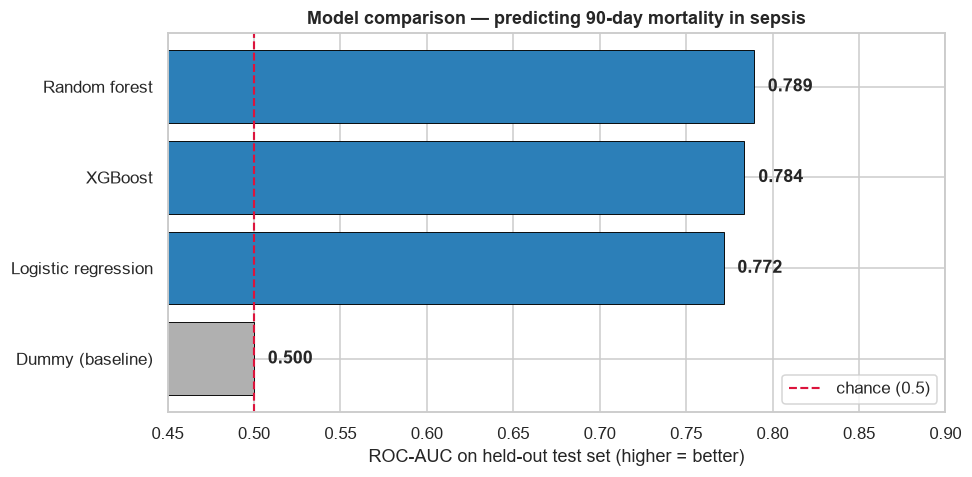

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = results.sort_values("test_AUC")
colors = ["#b0b0b0" if m.startswith("Dummy") else "#2c7fb8" for m in order["model"]]
bars = ax.barh(order["model"], order["test_AUC"], color=colors, edgecolor="black", linewidth=.6)
ax.axvline(0.5, ls="--", color="crimson", lw=1.4, label="chance (0.5)")
for b, v in zip(bars, order["test_AUC"]):
    ax.text(v + .008, b.get_y() + b.get_height()/2, f"{v:.3f}", va="center", fontweight="bold")
ax.set_xlim(0.45, 0.9)
ax.set_xlabel("ROC-AUC on held-out test set (higher = better)")
ax.set_title("Model comparison — predicting 90-day mortality in sepsis", fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

**How to read it.** Every real model clears the chance line by a wide margin. The gradient-boosted
and forest models edge out plain logistic regression by capturing non-linear interactions — but even
"simple" logistic regression is a strong, interpretable performer.

Let's also look at the actual **ROC curves**, which show the trade-off between catching deaths
(sensitivity) and false alarms (1 − specificity) across every threshold.

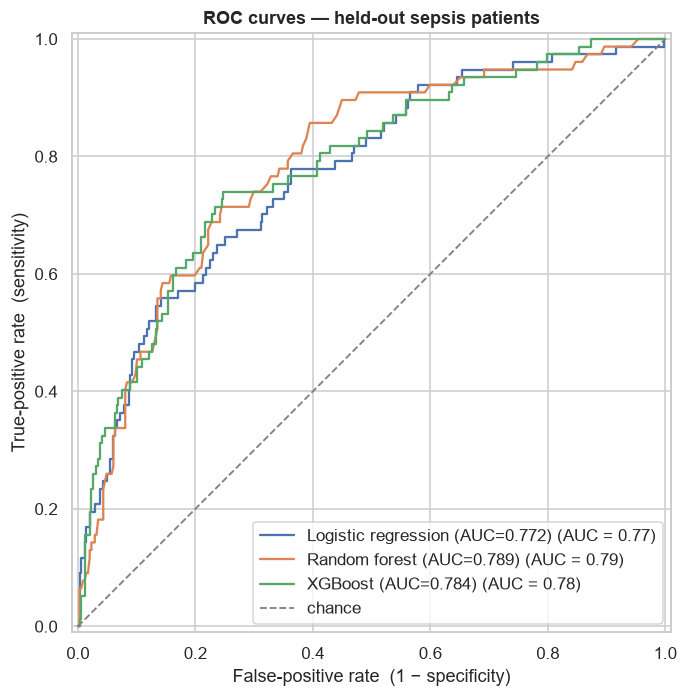

In [14]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name, model, auc in [("Logistic regression", logreg, logreg_auc),
                         ("Random forest", rf, rf_auc),
                         ("XGBoost", xgb, xgb_auc)]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax,
                                   name=f"{name} (AUC={auc:.3f})")
ax.plot([0, 1], [0, 1], ls="--", color="gray", lw=1.2, label="chance")
ax.set_title("ROC curves — held-out sepsis patients", fontweight="bold")
ax.set_xlabel("False-positive rate  (1 − specificity)")
ax.set_ylabel("True-positive rate  (sensitivity)")
ax.legend(loc="lower right"); plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** A single test-set number can be lucky or unlucky — it depends on *which*
> 25% of patients happened to land in the test set. To trust a model we need to know how stable that
> score is. Enter cross-validation.

## 🔁 Cross-validation — don't trust a single split

**Cross-validation** repeats the train/test game several times over different slices of the data and
reports the **mean ± spread** of the score. `StratifiedKFold(5)` cuts the data into 5 folds (each
keeping the 18% mortality rate); each fold takes a turn as the test set while the other four train.
Five honest AUCs instead of one — far more trustworthy.

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
models = {"Logistic regression": logreg, "Random forest": rf, "XGBoost": xgb}

cv_rows = []
for name, model in models.items():
    scores = cross_val_score(model, X, y, scoring="roc_auc", cv=cv, n_jobs=-1)
    cv_rows.append({"model": name, "cv_AUC_mean": scores.mean(),
                    "cv_AUC_std": scores.std(), "folds": scores.round(3)})
    print(f"{name:<22} AUC = {scores.mean():.3f} ± {scores.std():.3f}   folds={np.round(scores,3)}")

cv_df = pd.DataFrame(cv_rows)

Logistic regression    AUC = 0.783 ± 0.029   folds=[0.792 0.821 0.801 0.739 0.762]


Random forest          AUC = 0.788 ± 0.028   folds=[0.81  0.761 0.822 0.749 0.795]


XGBoost                AUC = 0.782 ± 0.025   folds=[0.808 0.757 0.809 0.748 0.791]


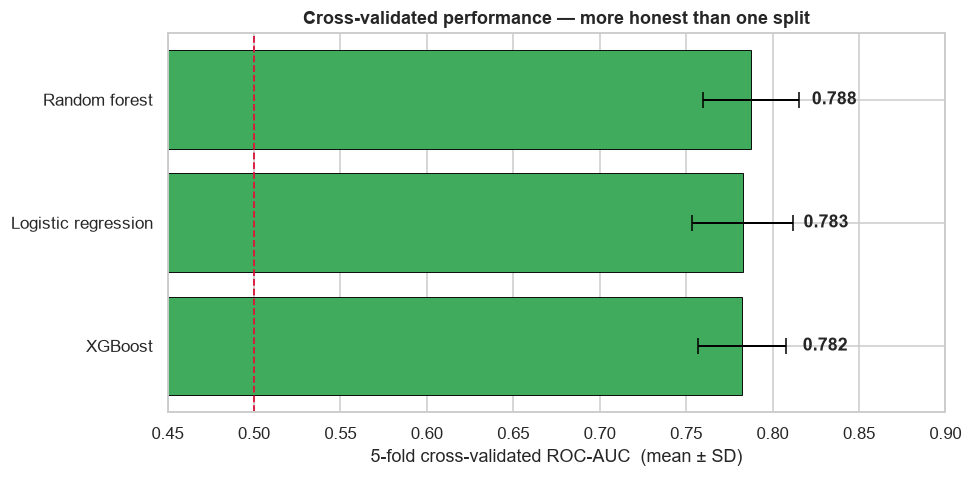

In [16]:
fig, ax = plt.subplots(figsize=(9, 4.5))
order = cv_df.sort_values("cv_AUC_mean")
ax.barh(order["model"], order["cv_AUC_mean"], xerr=order["cv_AUC_std"],
        color="#41ab5d", edgecolor="black", linewidth=.6,
        error_kw=dict(ecolor="black", capsize=5, lw=1.3))
for y_pos, (m, v) in enumerate(zip(order["model"], order["cv_AUC_mean"])):
    ax.text(v + order["cv_AUC_std"].max() + .006, y_pos, f"{v:.3f}", va="center", fontweight="bold")
ax.axvline(0.5, ls="--", color="crimson", lw=1.2)
ax.set_xlim(0.45, 0.9)
ax.set_xlabel("5-fold cross-validated ROC-AUC  (mean ± SD)")
ax.set_title("Cross-validated performance — more honest than one split", fontweight="bold")
plt.tight_layout(); plt.show()

> 🧠 **Clinical takeaway.** The cross-validated AUCs (≈0.76–0.80) sit close to the single-split
> numbers *and* the spread across folds is small (±0.02–0.03). That stability is what lets you report
> a model's performance with a straight face. A model whose AUC swings wildly between folds is
> fragile — treat its headline number with suspicion.

## 🔍 What is the model looking at? (feature-importance teaser)

A model that predicts well is more trusted when its reasoning matches clinical intuition. The random
forest can tell us which features it relied on most (`feature_importances_`). This is a **quick,
rough** view — it can be biased toward high-cardinality features and says nothing about *direction*.
Notebook 07 replaces it with **SHAP**, which is far more faithful. For now, a first look:

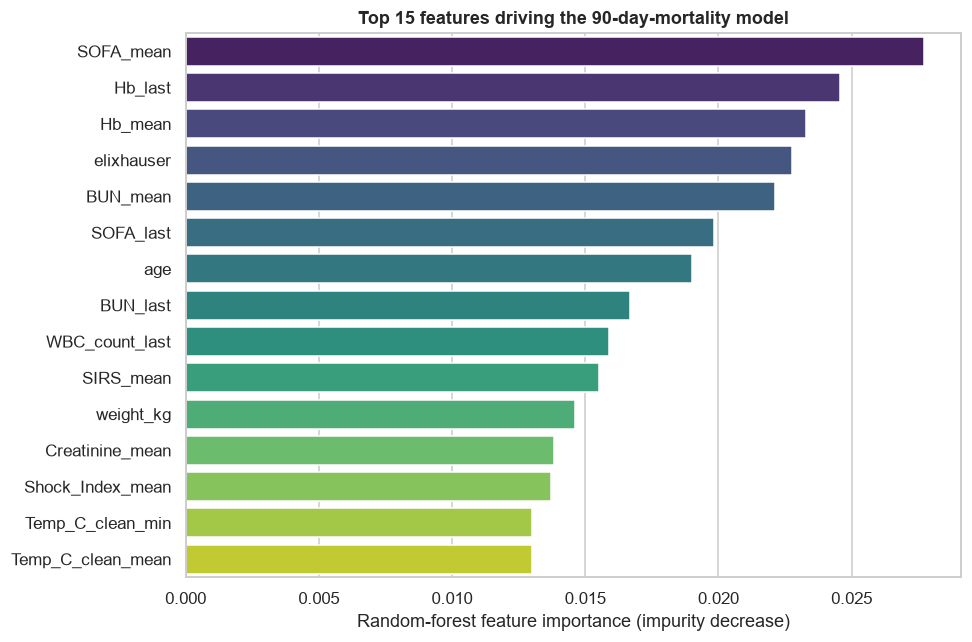

Top 5: ['SOFA_mean', 'Hb_last', 'Hb_mean', 'elixhauser', 'BUN_mean']


In [17]:
# Pull the fitted forest out of the pipeline and rank its top features
forest = rf.named_steps["clf"]
imp = (pd.Series(forest.feature_importances_, index=X.columns)
         .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=imp.values, y=imp.index, hue=imp.index, palette="viridis",
            legend=False, ax=ax)
ax.set_xlabel("Random-forest feature importance (impurity decrease)")
ax.set_ylabel("")
ax.set_title("Top 15 features driving the 90-day-mortality model", fontweight="bold")
plt.tight_layout(); plt.show()

print("Top 5:", list(imp.head().index))

**How to read it.** The model leans on exactly the markers a clinician would name: **age**,
**length of stay / number of blocks**, **SOFA**, **arterial lactate**, and **BUN/creatinine** (renal
function). It has re-discovered organ-failure and tissue-hypoxia signals from the raw table alone.

> 🧠 **Clinical takeaway.** Feature importance is a *sanity check*, not an explanation. If a model's
> top feature were something clinically absurd (or an ID column), that's a red flag for leakage or a
> bug. Here the ranking is reassuringly physiological — but to explain *individual* predictions and
> the *direction* of each effect, we need SHAP (Notebook 07).

## ✏️ Your turn

Time to drive. Fill in the `# TODO` cells; a worked solution hides under each one.

### Exercise 1 — Beat the baseline with a decision tree
Train a single `DecisionTreeClassifier(max_depth=3, class_weight="balanced",
random_state=RANDOM_STATE)` inside a pipeline (impute → tree), fit on the training set, and print its
**test ROC-AUC**. Does one shallow tree beat the dummy? Does it beat the forest?

In [18]:
from sklearn.tree import DecisionTreeClassifier

# TODO: build a Pipeline (SimpleImputer median -> DecisionTreeClassifier),
#       fit on X_train/y_train, and print the test ROC-AUC.
tree = None


<details><summary>💡 Show solution</summary>

```python
from sklearn.tree import DecisionTreeClassifier

tree = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("clf",    DecisionTreeClassifier(max_depth=3, class_weight="balanced",
                                      random_state=RANDOM_STATE)),
])
tree.fit(X_train, y_train)
tree_auc = roc_auc_score(y_test, tree.predict_proba(X_test)[:, 1])
print(f"Decision tree (depth 3)  ROC-AUC = {tree_auc:.3f}")
# Beats the dummy (0.50) comfortably, but a single shallow tree underperforms the
# 400-tree forest — averaging many trees is what makes the forest strong.
```
</details>

### Exercise 2 — How much does `class_weight` matter?
Refit the logistic-regression pipeline **without** `class_weight="balanced"` (the default). Compare
its test AUC *and* how many deaths it flags at the default 0.5 threshold
(`confusion_matrix(y_test, model.predict(X_test))`). What does balancing buy you?

In [19]:
from sklearn.metrics import confusion_matrix

# TODO: build a logistic-regression pipeline with NO class_weight, fit it,
#       and compare AUC + confusion matrix against the balanced version.


<details><summary>💡 Show solution</summary>

```python
from sklearn.metrics import confusion_matrix

plain = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale",  StandardScaler()),
    ("clf",    LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),  # no balancing
])
plain.fit(X_train, y_train)

plain_auc = roc_auc_score(y_test, plain.predict_proba(X_test)[:, 1])
print(f"Unbalanced AUC = {plain_auc:.3f}   vs balanced AUC = {logreg_auc:.3f}")
print("Unbalanced confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(y_test, plain.predict(X_test)))
print("Balanced confusion matrix:")
print(confusion_matrix(y_test, logreg.predict(X_test)))
# AUC (a threshold-free ranking metric) barely changes. But at the 0.5 threshold the
# UNBALANCED model predicts almost everyone survives -> it misses most deaths (big FN
# count). Balancing shifts the operating point so the model actually flags at-risk
# patients. Metric choice + threshold, not just AUC, decide clinical usefulness (Nb 06).
```
</details>

### Exercise 3 — Which features carry the signal?
Rebuild `X` using **only the 5 features** the forest ranked highest, retrain the XGBoost model on
that slim table, and report its cross-validated AUC. How close is 5 features to all 104?

In [20]:
# TODO: take the top-5 feature names from `imp`, subset X, and run
#       cross_val_score on a fresh XGBClassifier. Print mean +/- std AUC.
top5 = None


<details><summary>💡 Show solution</summary>

```python
top5 = list(imp.head(5).index)
X_small = X[top5]

xgb_small = XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, eval_metric="logloss",
    scale_pos_weight=spw, random_state=RANDOM_STATE, n_jobs=-1)

scores = cross_val_score(xgb_small, X_small, y, scoring="roc_auc", cv=cv, n_jobs=-1)
print("Top-5 features:", top5)
print(f"XGBoost on 5 features:  AUC = {scores.mean():.3f} ± {scores.std():.3f}")
# A handful of organ-failure / perfusion markers recover most of the full-model AUC.
# Parsimonious models are easier to deploy, audit, and trust at the bedside.
```
</details>

## ✅ Recap

- We framed 90-day mortality as **supervised learning**: features `X`, label `y`, dropping the ID
  and the outcome-leaking `died_in_hosp`.
- We **split before touching the data**, using `stratify` to preserve the 18% mortality rate — and
  saw that raw time-series must be split **by patient** (`GroupShuffleSplit`) to avoid leakage.
- A **`DummyClassifier`** exposed the accuracy trap (82% accurate, AUC 0.50) and set the bar.
- We built leak-free **`Pipeline`s** (impute → scale → model) for **logistic regression**, and
  impute-only pipelines for **random forest** and **XGBoost**, handling imbalance with
  `class_weight` / `scale_pos_weight`.
- We compared them by **held-out ROC-AUC** and confirmed stability with **5-fold cross-validation**
  (≈0.76–0.80).
- A **feature-importance** teaser showed the model relies on age, SOFA, lactate and renal markers —
  clinically sensible.

## ➡️ Next

- **Notebook 06 — Evaluating models like a clinician:** confusion matrices, precision–recall,
  **threshold tuning** for a target sensitivity, and **calibration** (does "20% risk" really mean
  20%?).
- **Notebook 07 — Explainable AI with SHAP:** move from *which* features matter to *why* a specific
  patient was flagged.
- **Notebook 08 — Pitfalls & leakage:** we'll *measure* how much a bad split inflates these AUCs.


<!-- nav-footer -->
---

### ➡️ Next up — Notebook 06: Evaluating like a clinician

<a href="https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/06_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open Notebook 06 in Colab" height="32"/></a>

👉 **[Continue to Notebook 06 — Evaluating like a clinician](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/06_model_evaluation.ipynb)**

[⬅ Back to Notebook 04](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/04_time_series_feature_engineering.ipynb) · [🗺️ Course index](https://colab.research.google.com/github/lorenzkap/ML2026/blob/main/00_START_HERE.ipynb) · [📁 The course on GitHub](https://github.com/lorenzkap/ML2026)